# Advanced-step NMPC on the IDAES CSTR

`drto.asnmpc` runs the closed loop of the
[ideal NMPC page](cstr_ideal_nmpc.ipynb) with the horizon solve moved
off the measurement instant. The ideal loop solves at each measured
state and treats that solve as taking no time. The advanced-step loop of
Huang, Zavala, and Biegler (2009) solves during the sample instead, at
the state the model predicts for its end. When the measurement arrives,
it corrects that solution with one backsolve on the factorization the
solve kept, which the [advanced step page](cstr_advanced_step.ipynb)
shows for a single correction. This page runs both loops on the same
model and the same disturbance values and compares what they implement.

## The loop

Write $x_k$ for the measured state at sample $k$, $u_k$ for the move
implemented over the sample, $w_k$ for the disturbance values over it,
and $f(x, u, w)$ for the state the model reaches one sample after $x$.
The controller solves a horizon problem whose first moves, as a function
of the state it starts from, are $u^*(x)$. Each step of the loop then
does the following.

1. Implement $u_k$ on the process, and write $w_k$ into it.
2. Predict $\hat{x}_{k+1} = f(x_k, u_k, 0)$ on a predictor, the
   controller's own model with its disturbances at zero.
3. Solve the horizon problem at $\hat{x}_{k+1}$ with pounce, which keeps
   the factorization.
4. Simulate the process, giving the measurement
   $x_{k+1} = f(x_k, u_k, w_k)$.
5. Correct the solution to the measurement. To first order the next
   move is
   $$u_{k+1} = u^*(\hat{x}_{k+1}) + \frac{\partial u^*}{\partial x}\,(x_{k+1} - \hat{x}_{k+1}).$$

The first move $u_0$ comes from a full solve at $x_0$, since there is
no earlier solution to correct. The process is built from the same
model as the controller, so with $w_k = 0$ the prediction equals the
measurement, the correction is zero, and the loop implements the ideal
loop's moves.

## The declared model and its setpoint

The saponification CSTR of `models/idaes_cstr.py`, with an added noise
term in each balance that is zero unless the loop writes a value into
it. The builder returns the declared model with its targets read off a
steady simulation at zero duty and nominal feed, as on the ideal NMPC
page. Each loop calls it once for every model it builds: the controller
and the process for the ideal loop, and the predictor as well for the
advanced-step loop.

In [1]:
from functools import partial

import pyomo.environ as pyo

import drto
from models.idaes_cstr import DC_START, F_IN, VOLUME, build


def build_cstr_at_setpoint(N=10, h=1, disturbance=False):
    """The declared model with its targets read off a steady simulation.

    A builder in feature 006's sense: it returns the declared,
    undiscretized model, and its first two parameters are N and h with
    defaults.
    """
    m = build(N=N, h=h, disturbance=disturbance)
    ss = pyo.TransformationFactory("drto.steady_state_simulation").create_using(
        m, controls={m.fs.cstr.control_volume.heat.name: 0.0,
                     m.fs.cstr.inlet.flow_vol.name: F_IN})
    drto.initialize_steady_state(ss)
    drto.scaled_solve(ss)
    cvs = ss.fs.cstr.control_volume
    for j, ssp in (("NaOH", m.ss_naoh), ("EthylAcetate", m.ss_ea),
                   ("SodiumAcetate", m.ss_sa), ("Ethanol", m.ss_etoh)):
        ssp.set_value(pyo.value(cvs.material_holdup["Liq", j]))
    for j, sgn in (("NaOH", 1), ("EthylAcetate", 1),
                   ("SodiumAcetate", -1), ("Ethanol", -1)):
        m.mat0[j] = pyo.value(cvs.material_holdup["Liq", j]) + sgn * DC_START * VOLUME
    for k in m.eng_ss:
        m.eng_ss[k] = pyo.value(cvs.energy_holdup[k])
    return m


build_noisy_cstr = partial(build_cstr_at_setpoint, disturbance=True)


def largest_gaps(a, b):
    """Print each state's and move's largest gap between two histories."""
    for kind, x, y in (("state", a.states, b.states), ("move", a.moves, b.moves)):
        for name in x:
            gap = max(abs(p - q) for p, q in zip(x[name], y[name]))
            span = max(y[name]) - min(y[name])
            print(f"{kind:5s} {name:34s} largest gap {gap:9.3g}   range {span:9.3g}")

## Without disturbances

Both loops run ten samples from the hot start with the same options.
The controller gets the terminal segment, the first solves are
cold-started along an exponential profile, and `scale` writes the
flowsheet's magnitudes per unit on every model the loop builds. The
table gives, for each state and move, the largest gap between the two
histories against the range the ideal loop covers.

In [2]:
import time

options = dict(
    steps=10,
    dynamic_optimization={"infinite_horizon": True},
    initialize={"profile": "exponential", "time_constant": 0.3},
    scale={"J": 1e7, "W": 1e6},
)

tic = time.time()
ideal = drto.ideal_nmpc(build_cstr_at_setpoint, **options)
print(f"ideal loop:         {time.time() - tic:.0f} s")
tic = time.time()
advanced = drto.asnmpc(build_cstr_at_setpoint, **options)
print(f"advanced-step loop: {time.time() - tic:.0f} s")
print()
largest_gaps(advanced, ideal)

ideal loop:         6 s


advanced-step loop: 6 s

state material_holdup_Liq_NaOH           largest gap  5.61e-10   range        20
state material_holdup_Liq_EthylAcetate   largest gap  5.61e-10   range        20
state material_holdup_Liq_SodiumAcetate  largest gap  5.61e-10   range        20
state material_holdup_Liq_Ethanol        largest gap  5.61e-10   range        20
state energy_holdup[Liq]                 largest gap  6.62e-05   range  5.82e+07
move  heat                               largest gap  0.000104   range  3.94e+06
move  _flow_vol_inlet_ref                largest gap  5.36e-11   range     0.797


## Under process noise

Every balance now gets normal draws with the standard deviations and the
seed the ideal NMPC page uses. Both loops draw in the same order, so
they see the same values. The controller and the predictor plan without
the draws, so every measurement leaves its prediction and every
correction is nonzero.

pounce flags some of these corrections, as on the
[advanced step page](cstr_advanced_step.ipynb). The terminal segment's
pin slacks sit exactly at their zero bounds, so a linear step pushes
half of each pair out and pounce clamps it. The flag concerns the
slacks, not the moves, and the cell below counts the flags rather than
printing each one.

In [3]:
import warnings

noise = {"w_NaOH": 0.5, "w_EthylAcetate": 0.5, "w_SodiumAcetate": 0.5,
         "w_Ethanol": 0.5, "w_energy": 1e6}

ideal_noisy = drto.ideal_nmpc(build_noisy_cstr, disturbances=noise, seed=7, **options)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    advanced_noisy = drto.asnmpc(build_noisy_cstr, disturbances=noise, seed=7, **options)
for w in caught:
    assert "clamped" in str(w.message) and "_pin_" in str(w.message), str(w.message)
print(f"({len(caught)} pounce warnings: the tail's pin slacks clamped at their "
      f"zero bounds)")
print("same draws:", advanced_noisy.realizations == ideal_noisy.realizations)
print()
largest_gaps(advanced_noisy, ideal_noisy)

(6 pounce warnings: the tail's pin slacks clamped at their zero bounds)
same draws: True

state material_holdup_Liq_NaOH           largest gap   0.00544   range      20.2
state material_holdup_Liq_EthylAcetate   largest gap   0.00545   range      20.4
state material_holdup_Liq_SodiumAcetate  largest gap   0.00537   range      20.6
state material_holdup_Liq_Ethanol        largest gap   0.00525   range      20.5
state energy_holdup[Liq]                 largest gap       233   range  5.87e+07
move  heat                               largest gap       592   range  3.96e+06
move  _flow_vol_inlet_ref                largest gap  0.000532   range     0.797


## The advanced-step trajectories under noise

The plots draw the advanced-step loop's history the way the ideal NMPC
page draws the ideal loop's.

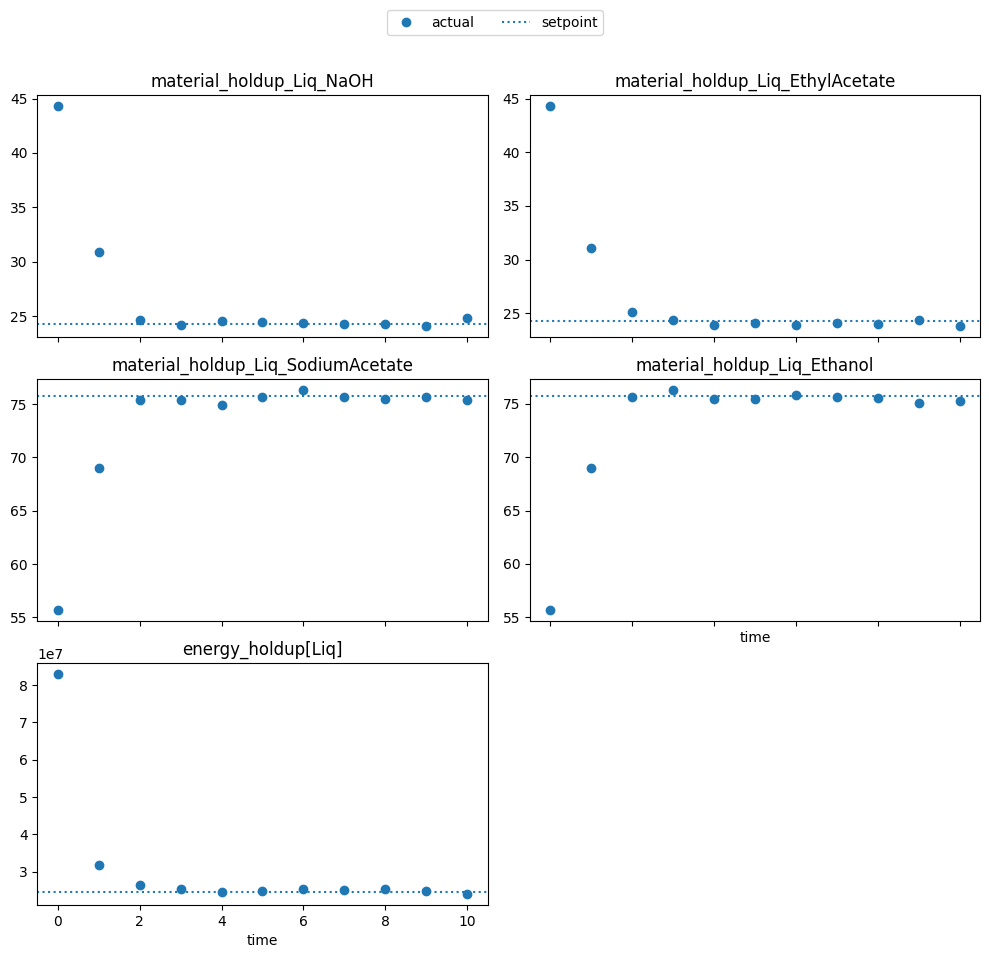

In [4]:
axes = drto.plot_states(advanced_noisy)

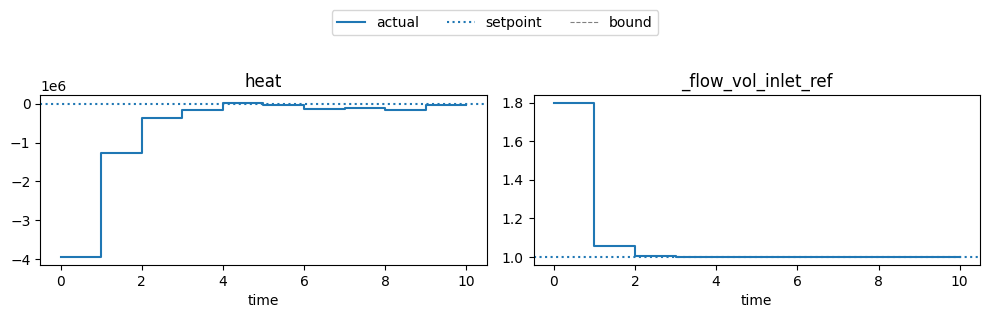

In [5]:
axes = drto.plot_controls(advanced_noisy)